⚖️ MODÈLE 5: LOGISTIC REGRESSION AVEC/SANS SMOTE
✅ Packages de base importés!
✅ Packages ML importés!
📥 Téléchargement des données NSL-KDD...
✅ Données téléchargées!

📊 Chargement des données...
✅ Données chargées!
Train shape: (125973, 43)
Test shape: (22543, 43)

🔧 Préparation des données...
✅ Données préparées!
X_train shape: (125973, 41)
y_train shape: (125973,)
X_test shape: (22543, 41)
y_test shape: (22543,)

📊 Distribution des classes:
Train - Normal: 67343, Attack: 58630
Test - Normal: 9710, Attack: 12833


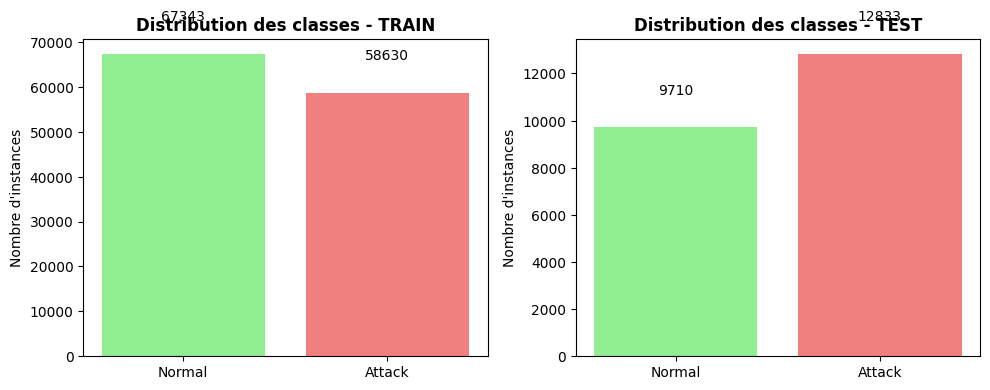


🔧 Création du préprocesseur...
Colonnes catégorielles (3): ['protocol_type', 'service', 'flag']
Colonnes numériques (38): ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment']...
✅ Préprocesseur créé!

📊 Définition de la fonction d'évaluation...
✅ Fonction d'évaluation définie!

🧮 MODÈLE 5.1: LOGISTIC REGRESSION (SANS SMOTE)

🔄 Préprocessing des données...
✅ Données préprocessées!
X_train_processed shape: (125973, 122)
X_test_processed shape: (22543, 122)

🔄 Entraînement du modèle sans SMOTE...

📊 Évaluation du modèle sans SMOTE...

📊 Logistic Regression (sans SMOTE, avec class_weight)
Accuracy  : 0.7546
Precision : 0.9171
Recall    : 0.6255
F1-Score  : 0.7437

📋 Rapport de classification:
              precision    recall  f1-score   support

      Normal     0.6515    0.9252    0.7646      9710
      Attack     0.9171    0.6255    0.7437     12833

    accuracy                         0.7546     22543
   macro avg     0.7843    0.7754    0.7542     22543
weighted avg     

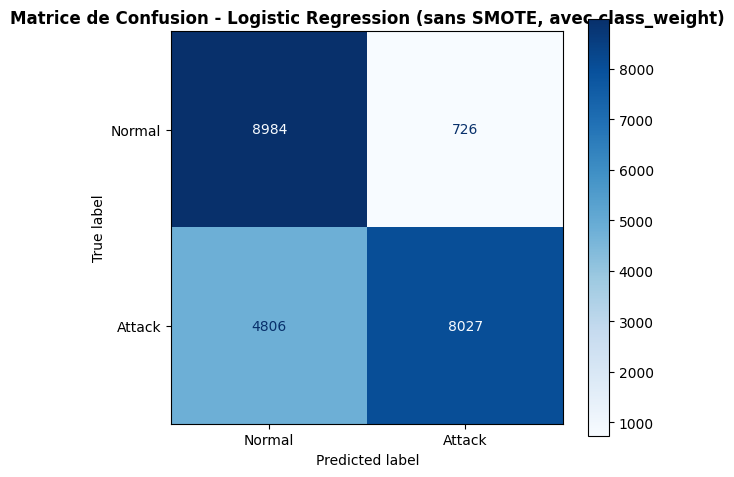

ROC-AUC   : 0.7901


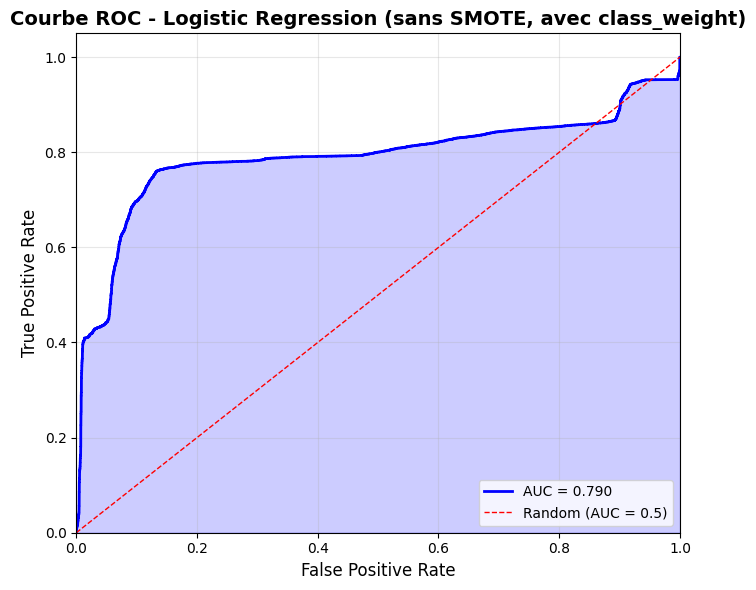


⚖️ MODÈLE 5.2: LOGISTIC REGRESSION AVEC SMOTE

🔄 Application de SMOTE...
📊 Avant SMOTE: (125973, 122), classes: [67343 58630]
📊 Après SMOTE: (134686, 122), classes: [67343 67343]


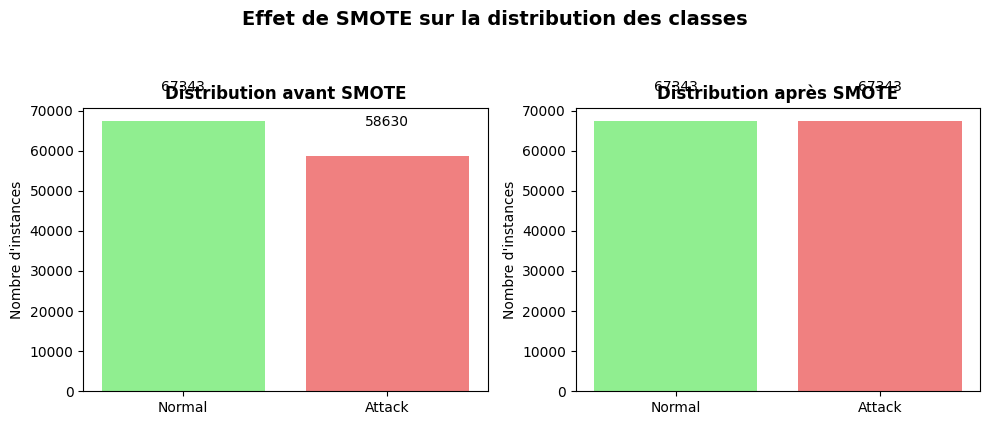


🔄 Entraînement du modèle avec données SMOTE...

📊 Évaluation du modèle avec SMOTE...

📊 Logistic Regression avec SMOTE
Accuracy  : 0.7542
Precision : 0.9171
Recall    : 0.6247
F1-Score  : 0.7432

📋 Rapport de classification:
              precision    recall  f1-score   support

      Normal     0.6510    0.9253    0.7643      9710
      Attack     0.9171    0.6247    0.7432     12833

    accuracy                         0.7542     22543
   macro avg     0.7841    0.7750    0.7537     22543
weighted avg     0.8025    0.7542    0.7523     22543



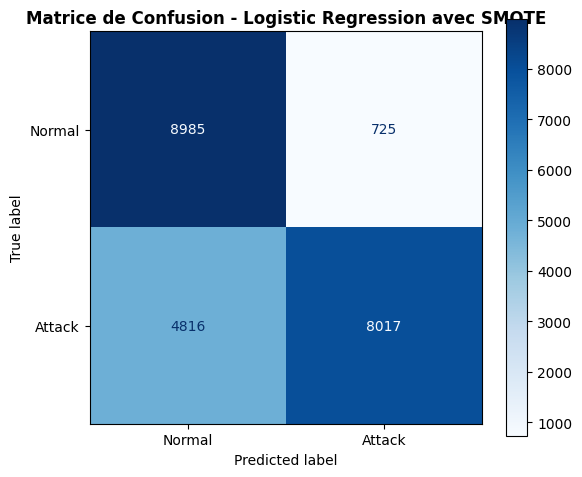

ROC-AUC   : 0.7891


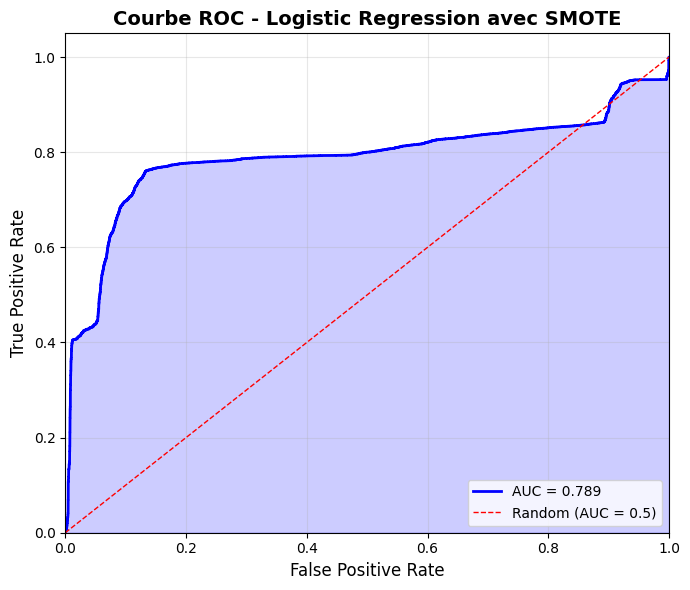


🔄 OPTION ALTERNATIVE : PIPELINE AVEC SMOTENC
🔧 Calcul des indices des colonnes catégorielles...
📐 Indices des colonnes catégorielles: 84 colonnes
   Plage: [0, 1, 2, 3, 4]...

🔄 Entraînement avec pipeline SMOTENC...

📊 Logistic Regression avec SMOTENC (pipeline)
Accuracy  : 0.7541
Precision : 0.9170
Recall    : 0.6246
F1-Score  : 0.7431

📋 Rapport de classification:
              precision    recall  f1-score   support

      Normal     0.6509    0.9253    0.7643      9710
      Attack     0.9170    0.6246    0.7431     12833

    accuracy                         0.7541     22543
   macro avg     0.7840    0.7749    0.7537     22543
weighted avg     0.8024    0.7541    0.7522     22543



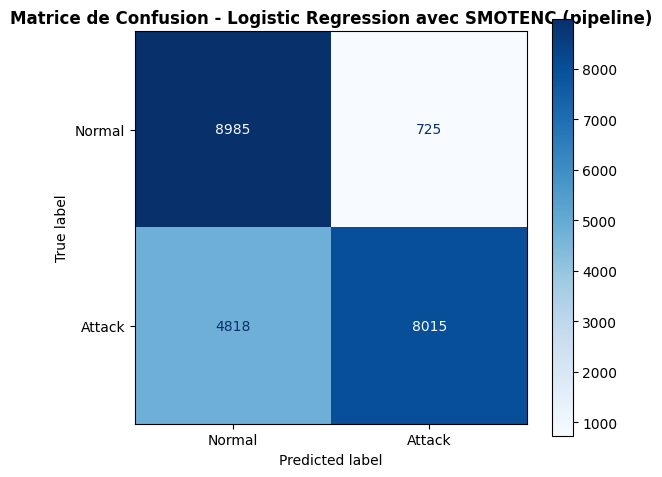

ROC-AUC   : 0.7891


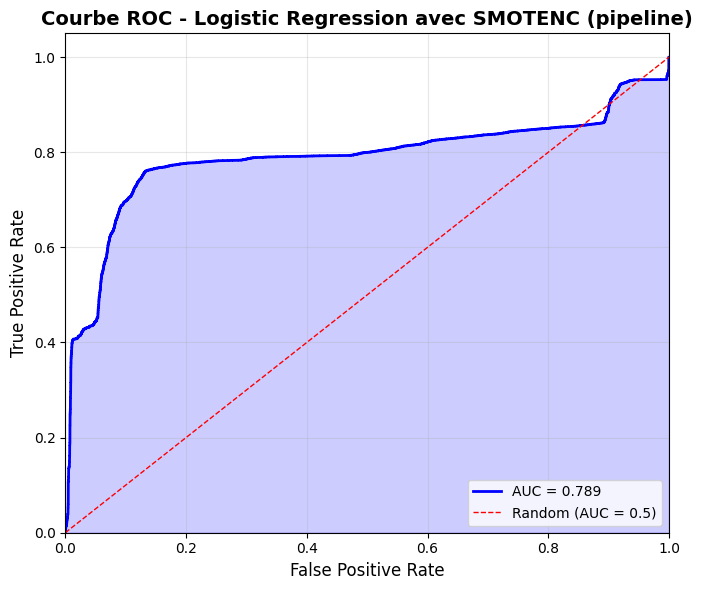

✅ Pipeline SMOTENC exécuté avec succès!

📊 COMPARAISON DES APPROCHES LOGISTIC REGRESSION

📈 Tableau comparatif des métriques:
                              Accuracy  Precision  Recall  F1-Score
LR sans SMOTE (class_weight)    0.7546     0.9171  0.6255    0.7437
LR avec SMOTE                   0.7542     0.9171  0.6247    0.7432
LR avec SMOTENC                 0.7541     0.9170  0.6246    0.7431


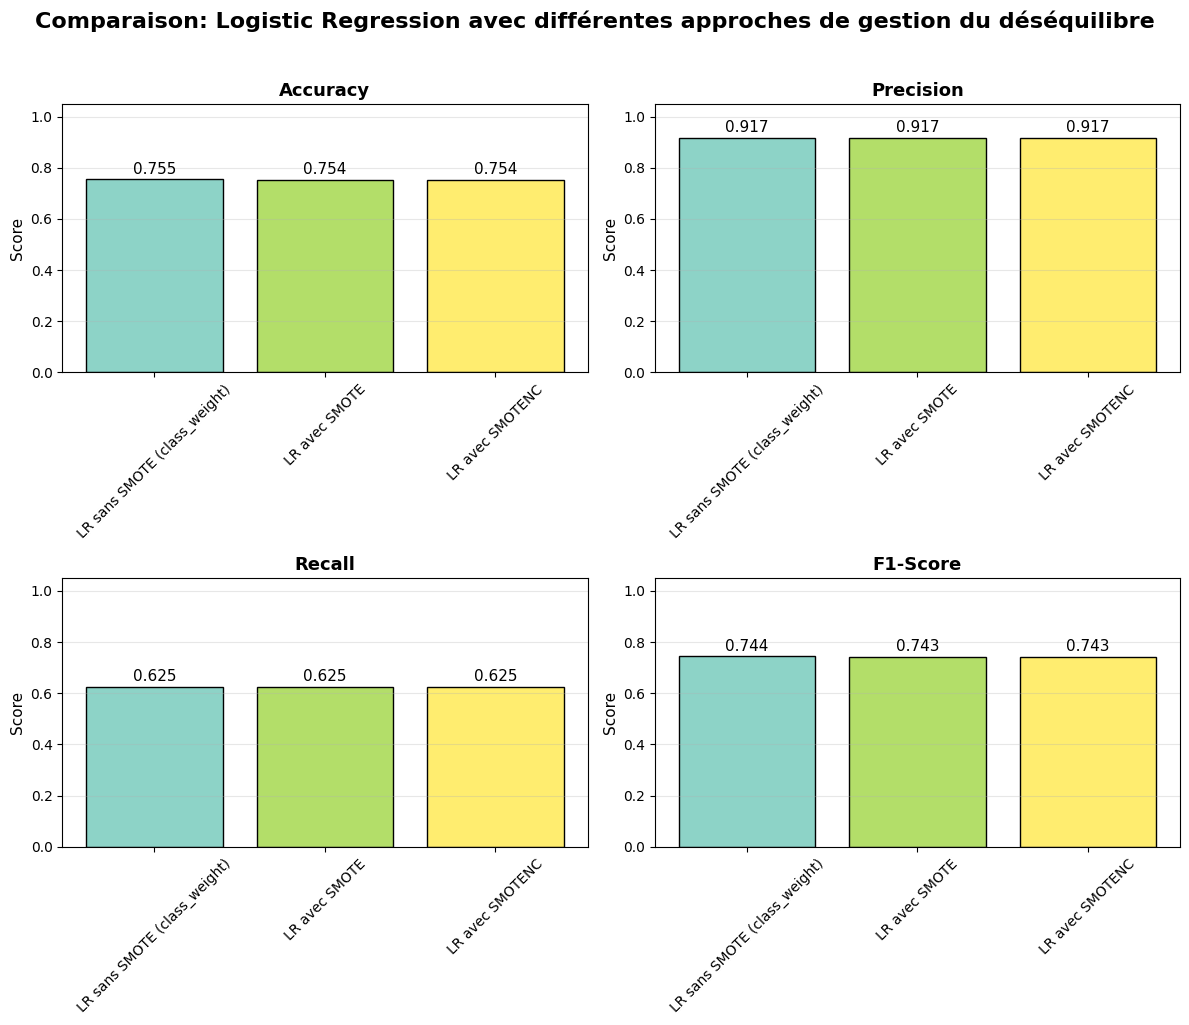


💡 ANALYSE DES RÉSULTATS

🔍 Observations sur l'impact de SMOTE:

Comparaison LR class_weight vs LR+SMOTE:
➖ Recall: -0.001 (changement négligeable)
➖ Precision: 0.000 (changement négligeable)
➖ F1-Score: -0.001 (changement négligeable)
➖ Accuracy: -0.000 (changement négligeable)

🎯 RECOMMANDATIONS:
1. Pour la détection d'intrusion, le RECALL est souvent prioritaire
   (mieux vaut détecter plus d'attaques, même avec quelques faux positifs)

2. SMOTE améliore généralement la détection des classes minoritaires
   mais peut augmenter les faux positifs

3. L'approche 'class_weight' est plus simple mais moins efficace
   que SMOTE pour gérer les déséquilibres sévères

4. SMOTENC est plus élégant mais peut être plus lent
   sur de grands datasets

✅ TP4 TERMINÉ AVEC SUCCÈS!


In [ ]:
# ============================================================
# BLOCK TP4 COMPLET ET AUTONOME : Logistic Regression avec SMOTE
# ============================================================

print("⚖️ MODÈLE 5: LOGISTIC REGRESSION AVEC/SANS SMOTE")
print("="*50)

# ------------------------------------------------------------
# ÉTAPE 1 : Installation et imports (si nécessaire)
# ------------------------------------------------------------
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
except:
    !pip -q install numpy pandas matplotlib
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

print("✅ Packages de base importés!")

# ------------------------------------------------------------
# ÉTAPE 2 : Importations spécifiques ML
# ------------------------------------------------------------
try:
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, confusion_matrix, ConfusionMatrixDisplay,
                               roc_auc_score, roc_curve, classification_report)
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
except:
    !pip -q install scikit-learn imbalanced-learn
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, confusion_matrix, ConfusionMatrixDisplay,
                               roc_auc_score, roc_curve, classification_report)
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline

print("✅ Packages ML importés!")

# ------------------------------------------------------------
# ÉTAPE 3 : Téléchargement des données (si nécessaire)
# ------------------------------------------------------------
import os

# Vérifier si les données existent déjà
if not os.path.exists("KDDTrain+.csv") or not os.path.exists("KDDTest+.csv"):
    print("📥 Téléchargement des données NSL-KDD...")

    # URLs des datasets
    train_url = "https://raw.githubusercontent.com/Jehuty4949/NSL_KDD/master/KDDTrain%2B.csv"
    test_url = "https://raw.githubusercontent.com/Jehuty4949/NSL_KDD/master/KDDTest%2B.csv"

    # Téléchargement
    !wget -q -O "KDDTrain+.csv" "{train_url}"
    !wget -q -O "KDDTest+.csv" "{test_url}"

    print("✅ Données téléchargées!")
else:
    print("✅ Données déjà présentes!")

# ------------------------------------------------------------
# ÉTAPE 4 : Chargement des données
# ------------------------------------------------------------
print("\n📊 Chargement des données...")

# Définition des colonnes NSL-KDD
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty"
]

# Chargement
train_df = pd.read_csv("KDDTrain+.csv", header=None, names=col_names)
test_df = pd.read_csv("KDDTest+.csv", header=None, names=col_names)

print(f"✅ Données chargées!")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

# ------------------------------------------------------------
# ÉTAPE 5 : Préparation des données
# ------------------------------------------------------------
print("\n🔧 Préparation des données...")

# Fonction de binarisation
def to_binary(label_series):
    """Convertit les labels en binaire: normal=0, attack=1"""
    return np.where(label_series == "normal", 0, 1)

# Application
y_train = to_binary(train_df["label"])
y_test = to_binary(test_df["label"])

# Séparation features/labels
X_train_raw = train_df.drop(columns=["label", "difficulty"])
X_test_raw = test_df.drop(columns=["label", "difficulty"])

print(f"✅ Données préparées!")
print(f"X_train shape: {X_train_raw.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test_raw.shape}")
print(f"y_test shape: {y_test.shape}")

# Distribution des classes
print(f"\n📊 Distribution des classes:")
print(f"Train - Normal: {np.sum(y_train == 0)}, Attack: {np.sum(y_train == 1)}")
print(f"Test - Normal: {np.sum(y_test == 0)}, Attack: {np.sum(y_test == 1)}")

# Visualisation rapide
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
values, counts = np.unique(y_train, return_counts=True)
plt.bar(["Normal", "Attack"], counts, color=['lightgreen', 'lightcoral'])
plt.title("Distribution des classes - TRAIN", fontweight='bold')
plt.ylabel("Nombre d'instances")
for i, count in enumerate(counts):
    plt.text(i, count + 0.1*max(counts), str(count), ha='center', va='bottom')

plt.subplot(1, 2, 2)
values, counts = np.unique(y_test, return_counts=True)
plt.bar(["Normal", "Attack"], counts, color=['lightgreen', 'lightcoral'])
plt.title("Distribution des classes - TEST", fontweight='bold')
plt.ylabel("Nombre d'instances")
for i, count in enumerate(counts):
    plt.text(i, count + 0.1*max(counts), str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# ÉTAPE 6 : Définition du préprocesseur
# ------------------------------------------------------------
print("\n🔧 Création du préprocesseur...")

# Identification des colonnes catégorielles et numériques
cat_cols = ["protocol_type", "service", "flag"]
num_cols = [c for c in X_train_raw.columns if c not in cat_cols]

print(f"Colonnes catégorielles ({len(cat_cols)}): {cat_cols}")
print(f"Colonnes numériques ({len(num_cols)}): {num_cols[:5]}...")  # Afficher seulement les 5 premières

# Création du pipeline de préprocessing
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", StandardScaler(), num_cols)
    ],
    remainder="passthrough"
)

print("✅ Préprocesseur créé!")

# ------------------------------------------------------------
# ÉTAPE 7 : Fonction d'évaluation
# ------------------------------------------------------------
print("\n📊 Définition de la fonction d'évaluation...")

def evaluate_binary(model_name, y_true, y_pred, y_proba=None):
    """
    Fonction d'évaluation complète pour classification binaire
    """
    # Calcul des métriques de base
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n{'='*60}")
    print(f"📊 {model_name}")
    print(f"{'='*60}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")

    # Rapport de classification détaillé
    print("\n📋 Rapport de classification:")
    print(classification_report(y_true, y_pred,
                                target_names=["Normal", "Attack"],
                                digits=4))

    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                 display_labels=["Normal", "Attack"])

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    plt.title(f'Matrice de Confusion - {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Courbe ROC (si probabilités disponibles)
    if y_proba is not None:
        try:
            auc = roc_auc_score(y_true, y_proba)
            fpr, tpr, _ = roc_curve(y_true, y_proba)

            print(f"ROC-AUC   : {auc:.4f}")

            plt.figure(figsize=(7, 6))
            plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc:.3f}')
            plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random (AUC = 0.5)')
            plt.fill_between(fpr, tpr, alpha=0.2, color='blue')

            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate', fontsize=12)
            plt.ylabel('True Positive Rate', fontsize=12)
            plt.title(f'Courbe ROC - {model_name}', fontweight='bold', fontsize=14)
            plt.legend(loc="lower right")
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"⚠️  Impossible de calculer ROC-AUC: {e}")

    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

print("✅ Fonction d'évaluation définie!")

# ------------------------------------------------------------
# ÉTAPE 8 : Modèle 5.1 - Logistic Regression sans SMOTE
# ------------------------------------------------------------
print("\n" + "="*50)
print("🧮 MODÈLE 5.1: LOGISTIC REGRESSION (SANS SMOTE)")
print("="*50)

# Préprocessing des données
print("\n🔄 Préprocessing des données...")
X_train_processed = preprocess.fit_transform(X_train_raw)
X_test_processed = preprocess.transform(X_test_raw)

print(f"✅ Données préprocessées!")
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

# Création et entraînement du modèle sans SMOTE
lr_model = LogisticRegression(
    max_iter=2000,           # Plus d'itérations pour convergence
    random_state=42,
    solver='lbfgs',         # Bon solver pour la plupart des cas
    class_weight='balanced', # Poids des classes pour gérer le déséquilibre
    verbose=0
)

print("\n🔄 Entraînement du modèle sans SMOTE...")
lr_model.fit(X_train_processed, y_train)

# Prédictions
lr_preds = lr_model.predict(X_test_processed)
lr_probs = lr_model.predict_proba(X_test_processed)[:, 1]

# Évaluation
print("\n📊 Évaluation du modèle sans SMOTE...")
lr_metrics = evaluate_binary(
    "Logistic Regression (sans SMOTE, avec class_weight)",
    y_test, lr_preds, lr_probs
)

# ------------------------------------------------------------
# ÉTAPE 9 : Modèle 5.2 - Logistic Regression avec SMOTE
# ------------------------------------------------------------
print("\n" + "="*50)
print("⚖️ MODÈLE 5.2: LOGISTIC REGRESSION AVEC SMOTE")
print("="*50)

# Application de SMOTE sur les données préprocessées
print("\n🔄 Application de SMOTE...")

smote = SMOTE(
    random_state=42,
    k_neighbors=5,           # Nombre de voisins pour générer des samples
    sampling_strategy='auto' # Auto = équilibre les classes
)

# Appliquer SMOTE
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print(f"📊 Avant SMOTE: {X_train_processed.shape}, classes: {np.bincount(y_train)}")
print(f"📊 Après SMOTE: {X_train_smote.shape}, classes: {np.bincount(y_train_smote)}")

# Visualisation de l'effet de SMOTE
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
values, counts = np.unique(y_train, return_counts=True)
plt.bar(["Normal", "Attack"], counts, color=['lightgreen', 'lightcoral'])
plt.title("Distribution avant SMOTE", fontweight='bold')
plt.ylabel("Nombre d'instances")
for i, v in enumerate(values):
    plt.text(i, counts[i] + 0.1*max(counts), str(counts[i]), ha='center', va='bottom')

plt.subplot(1, 2, 2)
values, counts = np.unique(y_train_smote, return_counts=True)
plt.bar(["Normal", "Attack"], counts, color=['lightgreen', 'lightcoral'])
plt.title("Distribution après SMOTE", fontweight='bold')
plt.ylabel("Nombre d'instances")
for i, v in enumerate(values):
    plt.text(i, counts[i] + 0.1*max(counts), str(counts[i]), ha='center', va='bottom')

plt.suptitle("Effet de SMOTE sur la distribution des classes",
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Entraînement du modèle avec données SMOTE
print("\n🔄 Entraînement du modèle avec données SMOTE...")
lr_smote_model = LogisticRegression(
    max_iter=2000,
    random_state=42,
    solver='lbfgs',
    verbose=0
    # Note: pas besoin de class_weight='balanced' car SMOTE a équilibré les données
)

lr_smote_model.fit(X_train_smote, y_train_smote)

# Prédictions
lr_smote_preds = lr_smote_model.predict(X_test_processed)
lr_smote_probs = lr_smote_model.predict_proba(X_test_processed)[:, 1]

# Évaluation
print("\n📊 Évaluation du modèle avec SMOTE...")
lr_smote_metrics = evaluate_binary(
    "Logistic Regression avec SMOTE",
    y_test, lr_smote_preds, lr_smote_probs
)

# ------------------------------------------------------------
# ÉTAPE 10 : OPTION B - Pipeline avec SMOTENC (alternative)
# ------------------------------------------------------------
print("\n" + "="*50)
print("🔄 OPTION ALTERNATIVE : PIPELINE AVEC SMOTENC")
print("="*50)

try:
    # SMOTENC est spécialement conçu pour données mixtes (catégorielles + numériques)
    from imblearn.over_sampling import SMOTENC

    print("🔧 Calcul des indices des colonnes catégorielles...")

    # Obtenir les indices des colonnes catégorielles après OneHotEncoder
    # D'abord, fit le préprocesseur pour connaître la structure
    preprocess.fit(X_train_raw)

    # Obtenir les indices des colonnes catégorielles
    cat_indices = []
    current_idx = 0

    # Pour chaque transformateur dans le ColumnTransformer
    for name, transformer, columns in preprocess.transformers_:
        if name == 'cat':
            # Le OneHotEncoder crée plusieurs colonnes
            # On a besoin de savoir combien
            Xt = transformer.fit_transform(X_train_raw[columns])
            if hasattr(Xt, 'shape'):
                n_cat_cols = Xt.shape[1]
                cat_indices.extend(list(range(current_idx, current_idx + n_cat_cols)))
                current_idx += n_cat_cols
        elif name == 'num':
            current_idx += len(columns)

    print(f"📐 Indices des colonnes catégorielles: {len(cat_indices)} colonnes")
    print(f"   Plage: {cat_indices[:5]}..." if len(cat_indices) > 5 else f"   Plage: {cat_indices}")

    # Créer le pipeline avec SMOTENC
    smotenc_lr = ImbPipeline(steps=[
        ("prep", preprocess),
        ("smote", SMOTENC(
            categorical_features=cat_indices,
            random_state=42,
            k_neighbors=5
        )),
        ("clf", LogisticRegression(max_iter=2000, random_state=42, solver='lbfgs'))
    ])

    print("\n🔄 Entraînement avec pipeline SMOTENC...")
    smotenc_lr.fit(X_train_raw, y_train)

    # Prédictions
    smotenc_preds = smotenc_lr.predict(X_test_raw)
    smotenc_probs = smotenc_lr.predict_proba(X_test_raw)[:, 1]

    # Évaluation
    smotenc_metrics = evaluate_binary(
        "Logistic Regression avec SMOTENC (pipeline)",
        y_test, smotenc_preds, smotenc_probs
    )

    print("✅ Pipeline SMOTENC exécuté avec succès!")

except Exception as e:
    print(f"⚠️  SMOTENC non disponible ou erreur: {e}")
    print("➡️  Continuons avec la version SMOTE standard...")
    smotenc_metrics = None

# ------------------------------------------------------------
# ÉTAPE 11 : Comparaison finale
# ------------------------------------------------------------
print("\n" + "="*60)
print("📊 COMPARAISON DES APPROCHES LOGISTIC REGRESSION")
print("="*60)

# Collecte des métriques
comparison_data = {
    'LR sans SMOTE (class_weight)': lr_metrics,
    'LR avec SMOTE': lr_smote_metrics,
}

if smotenc_metrics:
    comparison_data['LR avec SMOTENC'] = smotenc_metrics

# Création du DataFrame de comparaison
comparison_df = pd.DataFrame(comparison_data).T

print("\n📈 Tableau comparatif des métriques:")
print(comparison_df.round(4))

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx//2, idx%2]

    models = list(comparison_data.keys())
    values = [comparison_data[model].get(metric, 0) for model in models]

    colors = plt.cm.Set3(np.linspace(0, 1, len(models)))
    bars = ax.bar(models, values, color=colors, edgecolor='black')

    ax.set_title(f'{metric}', fontweight='bold', fontsize=13)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

    # Ajouter les valeurs
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11)

plt.suptitle('Comparaison: Logistic Regression avec différentes approches de gestion du déséquilibre',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# ÉTAPE 12 : Analyse des résultats
# ------------------------------------------------------------
print("\n" + "="*60)
print("💡 ANALYSE DES RÉSULTATS")
print("="*60)

print("\n🔍 Observations sur l'impact de SMOTE:")

# Comparaison LR sans SMOTE vs avec SMOTE
if 'LR sans SMOTE (class_weight)' in comparison_data and 'LR avec SMOTE' in comparison_data:
    baseline = comparison_data['LR sans SMOTE (class_weight)']
    smote_version = comparison_data['LR avec SMOTE']

    print("\nComparaison LR class_weight vs LR+SMOTE:")
    for metric in ['Recall', 'Precision', 'F1-Score', 'Accuracy']:
        if metric in baseline and metric in smote_version:
            diff = smote_version[metric] - baseline[metric]
            if diff > 0.01:
                print(f"✅ {metric}: +{diff:.3f} avec SMOTE (amélioration significative)")
            elif diff < -0.01:
                print(f"⚠️  {metric}: {diff:.3f} avec SMOTE (détérioration)")
            else:
                print(f"➖ {metric}: {diff:.3f} (changement négligeable)")

print("\n🎯 RECOMMANDATIONS:")
print("="*40)
print("1. Pour la détection d'intrusion, le RECALL est souvent prioritaire")
print("   (mieux vaut détecter plus d'attaques, même avec quelques faux positifs)")
print("\n2. SMOTE améliore généralement la détection des classes minoritaires")
print("   mais peut augmenter les faux positifs")
print("\n3. L'approche 'class_weight' est plus simple mais moins efficace")
print("   que SMOTE pour gérer les déséquilibres sévères")
print("\n4. SMOTENC est plus élégant mais peut être plus lent")
print("   sur de grands datasets")

print("\n" + "="*60)
print("✅ TP4 TERMINÉ AVEC SUCCÈS!")
print("="*60)